===== TABULAR / MEDICAL DATA =====
Dataset could not be downloaded: HTTP Error 404: Not Found


===== ECG SIGNAL DATA =====
Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
Signal shape: (650000, 2)
Sampling frequency: 360
Number of annotations: 2274
Signal names: ['MLII', 'V5']


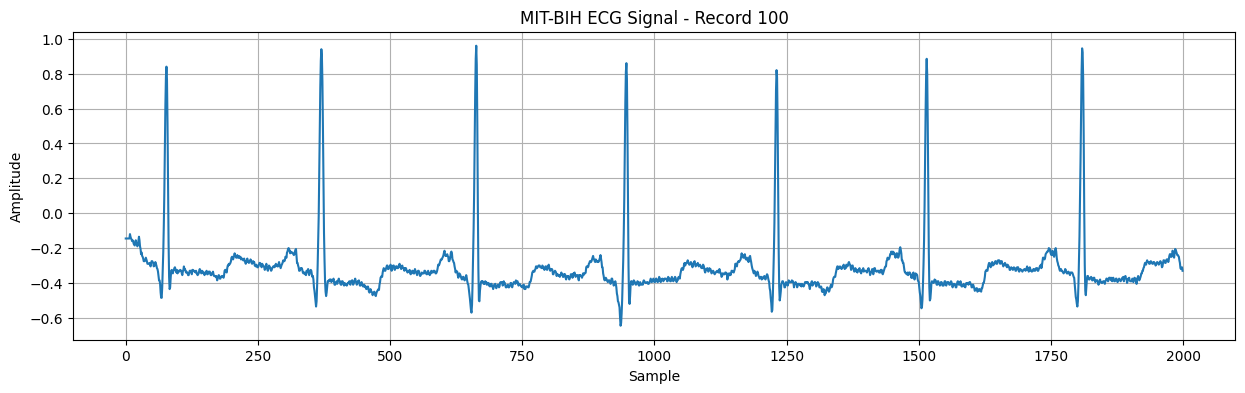

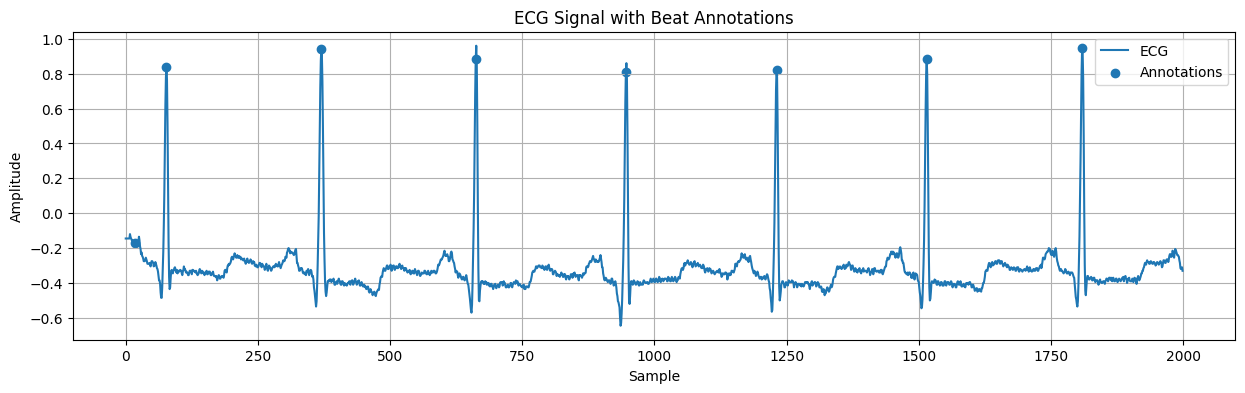


===== ECG STATISTICS =====
Mean RR interval: 0.7946 seconds
SDNN: 0.0488 seconds
Approximate mean heart rate: 75.51 BPM


===== TEXTUAL DATA =====
Original clinical note:

Patient reports chest pain during physical activity.
The patient experiences shortness of breath and mild fatigue.
Heart rate is elevated during exercise.
The patient has a history of hypertension.


Tokens:
['patient', 'reports', 'chest', 'pain', 'during', 'physical', 'activity', 'the', 'patient', 'experiences', 'shortness', 'of', 'breath', 'and', 'mild', 'fatigue', 'heart', 'rate', 'is', 'elevated', 'during', 'exercise', 'the', 'patient', 'has', 'a', 'history', 'of', 'hypertension']

Word frequency:
patient : 3
during : 2
the : 2
of : 2
reports : 1
chest : 1
pain : 1
physical : 1
activity : 1
experiences : 1
shortness : 1
breath : 1
and : 1
mild : 1
fatigue : 1
heart : 1
rate : 1
is : 1
elevated : 1
exercise : 1
has : 1
a : 1
history : 1
hypertension : 1

Important medical terms found:
['chest', 'pain', 'shortness

/tmp/ipykernel_1164/859633380.py:337: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image_array, mode="L")


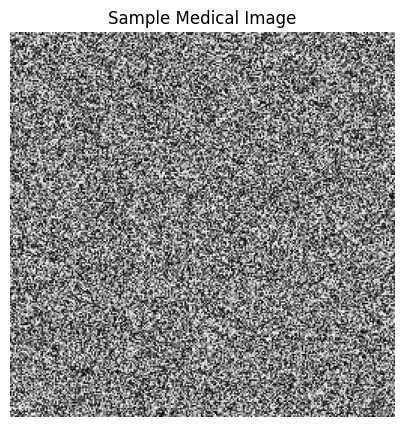

Original size: (256, 256)
Resized size: (128, 128)


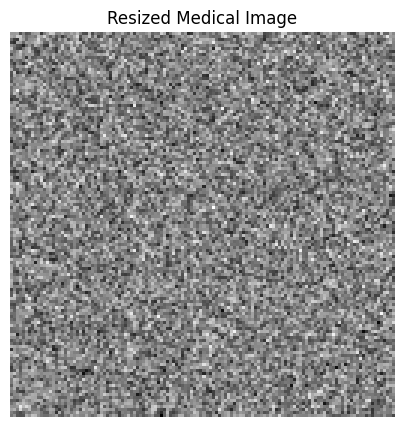



===== GENERIC FILE TYPE DETECTION =====
patient.csv -> Tabular CSV
clinical_note.txt -> Text
scan.dcm -> Medical Image DICOM
brain.nii -> Medical Image NIfTI
ecg.dat -> WFDB Signal
ecg.hea -> WFDB Header
ecg.atr -> WFDB Annotation
report.pdf -> PDF
xray.png -> Image PNG


===== DATA INSPECTION SUMMARY =====

ECG Signal
Type: NumPy Array
Shape: (650000, 2)
Data type: float64

Clinical Note
Type: Text
Characters: 199
Words: 29

Medical Image
Type: PIL Image
Size: (256, 256)
Mode: L

LAB EXPERIMENT 1 COMPLETED SUCCESSFULLY

Data modalities demonstrated:
1. Tabular data    -> CSV / DataFrame
2. Medical data    -> Heart Disease Dataset
3. Signal data     -> MIT-BIH ECG / WFDB
4. Text data       -> Clinical note
5. Image data      -> Grayscale medical-style image

Operations performed:
- Data loading
- Data inspection
- Missing-value handling
- Preprocessing
- Text tokenization
- Word-frequency analysis
- ECG visualization
- ECG annotation handling
- Image loading and resizing
- Basic clas

In [2]:

!pip -q install pandas numpy matplotlib scikit-learn wfdb pillow


import os
import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import wfdb




print("===== TABULAR / MEDICAL DATA =====")

# UCI Heart Disease dataset
url = (
    "https://raw.githubusercontent.com/"
    "ugis22/Heart-Disease-Prediction/master/dataset.csv"
)

try:
    heart_df = pd.read_csv(url)
    print("Dataset loaded successfully.")
except Exception as e:
    print("Dataset could not be downloaded:", e)
    heart_df = pd.DataFrame()

if not heart_df.empty:

    print("\nShape:")
    print(heart_df.shape)

    print("\nFirst 5 rows:")
    print(heart_df.head())

    print("\nColumn names:")
    print(heart_df.columns.tolist())

    print("\nData types:")
    print(heart_df.dtypes)

    print("\nMissing values:")
    print(heart_df.isnull().sum())




if not heart_df.empty:

    # Remove duplicate rows
    heart_df = heart_df.drop_duplicates()

    # Convert '?' to NaN if present
    heart_df = heart_df.replace("?", np.nan)

    # Convert columns to numeric where possible
    for col in heart_df.columns:
        heart_df[col] = pd.to_numeric(heart_df[col], errors="coerce")

    print("\nMissing values after conversion:")
    print(heart_df.isnull().sum())

    # Target column detection
    possible_targets = ["target", "num", "condition", "goal"]

    target_col = None
    for col in possible_targets:
        if col in heart_df.columns:
            target_col = col
            break

    if target_col is None:
        # Use last column as fallback
        target_col = heart_df.columns[-1]

    print("\nTarget column:", target_col)

    # Binary classification:
    # 0 = No disease
    # >0 = Disease
    y = (heart_df[target_col] > 0).astype(int)

    X = heart_df.drop(columns=[target_col])

    # Keep only numeric columns
    X = X.select_dtypes(include=[np.number])

    # Fill missing values
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X)

    # Standardization
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    print("\nFeature matrix shape:", X_scaled.shape)
    print("Target distribution:")
    print(y.value_counts())




if not heart_df.empty:

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("\n===== MODEL EVALUATION =====")
    print("Accuracy:", round(accuracy, 4))
    print("ROC AUC:", round(roc_auc, 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))




if not heart_df.empty:

    heart_df.hist(figsize=(14, 10))
    plt.suptitle("Heart Disease Dataset - Feature Distributions")
    plt.tight_layout()
    plt.show()



print("\n\n===== ECG SIGNAL DATA =====")

record_name = "100"

# Download record files into local directory
wfdb.dl_database(
    "mitdb",
    dl_dir="mitdb_sample",
    records=[record_name]
)

# Read ECG signal
record = wfdb.rdrecord(
    os.path.join("mitdb_sample", record_name)
)

# Read annotations
annotation = wfdb.rdann(
    os.path.join("mitdb_sample", record_name),
    "atr"
)

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)
print("Number of annotations:", len(annotation.sample))

print("Signal names:", record.sig_name)




samples_to_plot = 2000

ecg_signal = record.p_signal[:samples_to_plot, 0]

plt.figure(figsize=(15, 4))
plt.plot(ecg_signal)
plt.title("MIT-BIH ECG Signal - Record 100")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()




annotation_samples = annotation.sample[
    annotation.sample < samples_to_plot
]

plt.figure(figsize=(15, 4))
plt.plot(ecg_signal, label="ECG")

valid_annotation_samples = annotation_samples[
    annotation_samples < len(ecg_signal)
]

plt.scatter(
    valid_annotation_samples,
    ecg_signal[valid_annotation_samples],
    marker="o",
    label="Annotations"
)

plt.title("ECG Signal with Beat Annotations")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()




beat_samples = np.array(annotation.sample)


rr_intervals_samples = np.diff(beat_samples)


rr_intervals_seconds = rr_intervals_samples / record.fs


valid_rr = rr_intervals_seconds[
    (rr_intervals_seconds > 0.3) &
    (rr_intervals_seconds < 2.0)
]

if len(valid_rr) > 0:

    mean_rr = np.mean(valid_rr)
    sdnn = np.std(valid_rr)

    mean_hr = 60 / mean_rr

    print("\n===== ECG STATISTICS =====")
    print("Mean RR interval:", round(mean_rr, 4), "seconds")
    print("SDNN:", round(sdnn, 4), "seconds")
    print("Approximate mean heart rate:",
          round(mean_hr, 2), "BPM")




print("\n\n===== TEXTUAL DATA =====")

clinical_note = """
Patient reports chest pain during physical activity.
The patient experiences shortness of breath and mild fatigue.
Heart rate is elevated during exercise.
The patient has a history of hypertension.
"""

print("Original clinical note:")
print(clinical_note)



import re

clean_text = clinical_note.lower()

# Remove punctuation
clean_text = re.sub(r"[^a-zA-Z\s]", "", clean_text)

# Tokenization
tokens = clean_text.split()

print("\nTokens:")
print(tokens)




word_frequency = Counter(tokens)

print("\nWord frequency:")
for word, count in word_frequency.most_common():
    print(word, ":", count)




medical_keywords = [
    "chest",
    "pain",
    "shortness",
    "breath",
    "fatigue",
    "heart",
    "hypertension",
    "exercise"
]

found_keywords = [
    word for word in medical_keywords
    if word in tokens
]

print("\nImportant medical terms found:")
print(found_keywords)




print("\n\n===== IMAGE DATA =====")



image_array = np.random.randint(
    0,
    256,
    size=(256, 256),
    dtype=np.uint8
)

image = Image.fromarray(image_array, mode="L")

print("Image format:", image.format)
print("Image size:", image.size)
print("Image mode:", image.mode)



plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.title("Sample Medical Image")
plt.axis("off")
plt.show()



resized_image = image.resize((128, 128))

print("Original size:", image.size)
print("Resized size:", resized_image.size)

plt.figure(figsize=(5, 5))
plt.imshow(resized_image, cmap="gray")
plt.title("Resized Medical Image")
plt.axis("off")
plt.show()



print("\n\n===== GENERIC FILE TYPE DETECTION =====")

def detect_file_type(filename):
    ext = os.path.splitext(filename)[1].lower()

    mapping = {
        ".csv": "Tabular CSV",
        ".xls": "Excel",
        ".xlsx": "Excel",
        ".json": "JSON",
        ".txt": "Text",
        ".pdf": "PDF",
        ".html": "HTML",
        ".png": "Image PNG",
        ".jpg": "Image JPEG",
        ".jpeg": "Image JPEG",
        ".tiff": "Image TIFF",
        ".dcm": "Medical Image DICOM",
        ".nii": "Medical Image NIfTI",
        ".dat": "WFDB Signal",
        ".hea": "WFDB Header",
        ".atr": "WFDB Annotation",
    }

    return mapping.get(ext, "Unknown format")


files = [
    "patient.csv",
    "clinical_note.txt",
    "scan.dcm",
    "brain.nii",
    "ecg.dat",
    "ecg.hea",
    "ecg.atr",
    "report.pdf",
    "xray.png"
]

for file in files:
    print(file, "->", detect_file_type(file))




print("\n\n===== DATA INSPECTION SUMMARY =====")

def inspect_data(name, data):
    print(f"\n{name}")

    if isinstance(data, pd.DataFrame):
        print("Type: DataFrame")
        print("Shape:", data.shape)
        print("Missing values:", int(data.isnull().sum().sum()))

    elif isinstance(data, np.ndarray):
        print("Type: NumPy Array")
        print("Shape:", data.shape)
        print("Data type:", data.dtype)

    elif isinstance(data, Image.Image):
        print("Type: PIL Image")
        print("Size:", data.size)
        print("Mode:", data.mode)

    elif isinstance(data, str):
        print("Type: Text")
        print("Characters:", len(data))
        print("Words:", len(data.split()))

    else:
        print("Type:", type(data))


if not heart_df.empty:
    inspect_data("Heart Disease Dataset", heart_df)

inspect_data("ECG Signal", record.p_signal)
inspect_data("Clinical Note", clinical_note)
inspect_data("Medical Image", image)




print("\n============================================")
print("LAB EXPERIMENT 1 COMPLETED SUCCESSFULLY")
print("============================================")

print("""
Data modalities demonstrated:
1. Tabular data    -> CSV / DataFrame
2. Medical data    -> Heart Disease Dataset
3. Signal data     -> MIT-BIH ECG / WFDB
4. Text data       -> Clinical note
5. Image data      -> Grayscale medical-style image

Operations performed:
- Data loading
- Data inspection
- Missing-value handling
- Preprocessing
- Text tokenization
- Word-frequency analysis
- ECG visualization
- ECG annotation handling
- Image loading and resizing
- Basic classification
""")